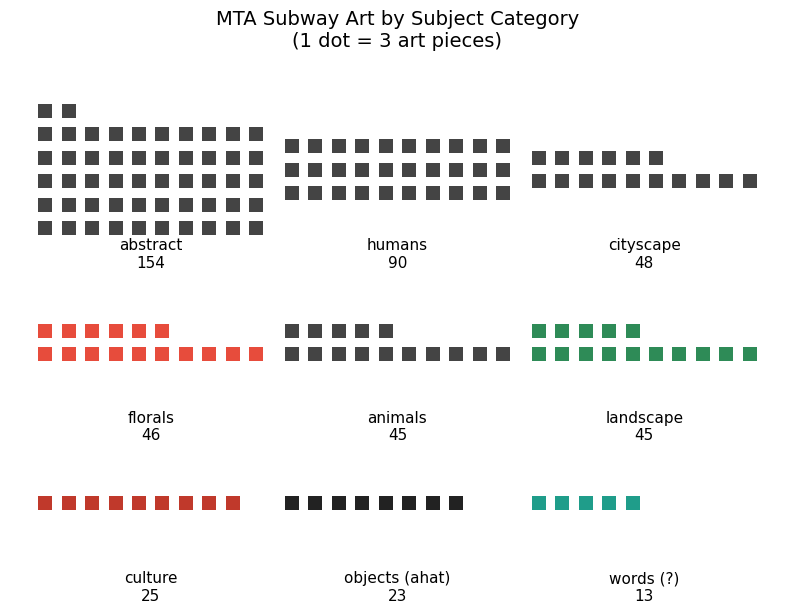

In [1]:
import math
import matplotlib.pyplot as plt

def draw_dot_icon(ax, count, center=(0, 0), *,
                  unit=3, cols=10, dot=0.12, gap=0.03,
                  color="#333333", marker="s"):
    """
    Draw a dot-matrix icon where 1 dot = `unit` items.
    center: (x,y) center position of the whole icon in plot coords
    cols: how many dots per row
    dot: marker size scale (visual)
    gap: spacing between dots
    """
    n = math.ceil(count / unit)
    rows = math.ceil(n / cols)

    # build grid positions, filled left-to-right, bottom-to-top
    xs, ys = [], []
    for i in range(n):
        c = i % cols
        r = i // cols
        xs.append(c * (dot + gap))
        ys.append(r * (dot + gap))

    # shift so the icon is centered at `center`
    width = (cols - 1) * (dot + gap)
    height = (rows - 1) * (dot + gap)
    xs = [x - width / 2 + center[0] for x in xs]
    ys = [y - height / 2 + center[1] for y in ys]

    ax.scatter(xs, ys, s=700 * dot, c=color, marker=marker, linewidths=0)

# ---- example data from your sheet ----
data = {
    "abstract": 154,
    "humans": 90,
    "cityscape": 48,
    "florals": 46,
    "animals": 45,
    "landscape": 45,
    "culture": 25,
    "objects (ahat)": 23,
    "words (?)": 13,
}

# pick colors per category (adjust to match your drawing)
colors = {
    "abstract": "#444444",
    "humans": "#444444",
    "cityscape": "#444444",
    "florals": "#E74C3C",
    "animals": "#444444",
    "landscape": "#2E8B57",
    "culture": "#C0392B",
    "objects (ahat)": "#222222",
    "words (?)": "#1F9D8A",
}

# layout positions (x,y) so you can place icons like your poster
positions = {
    "abstract": (-2.0,  1.4),
    "humans":   ( 0.0,  1.4),
    "cityscape":( 2.0,  1.4),
    "florals":  (-2.0,  0.0),
    "animals":  ( 0.0,  0.0),
    "landscape":( 2.0,  0.0),
    "culture":  (-2.0, -1.3),
    "objects (ahat)": (0.0, -1.3),
    "words (?)": ( 2.0, -1.3),
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_aspect("equal")
ax.axis("off")

for k, v in data.items():
    draw_dot_icon(
        ax, v, center=positions[k],
        unit=3, cols=10,
        dot=0.14, gap=0.05,
        color=colors.get(k, "#333333"),
        marker="s"  # "s" square; use "o" for circles
    )
    ax.text(positions[k][0], positions[k][1] - 0.55, f"{k}\n{v}",
            ha="center", va="top", fontsize=11)

ax.text(0, 2.4, "MTA Subway Art by Subject Category\n(1 dot = 3 art pieces)",
        ha="center", fontsize=14)

plt.show()